In [1]:
import pandas as pd
import nba_on_court as noc
import nba_api.stats.static.players as players
import nba_api.stats.endpoints.playergamelog as game_logs
import nba_api.stats.endpoints as stats
import numpy as np

if not hasattr(np, "in1d"):
    np.in1d = np.isin

In [2]:
raw_pbp_data= pd.read_csv('nba_data.csv').drop(columns='Unnamed: 0').rename(
    columns={'EVENTNUM':'GAME_EVENT_ID'})

In [3]:
raw_pbp_data

,GAME_ID,GAME_EVENT_ID,EVENTMSGTYPE,EVENTMSGACTIONTYPE,PERIOD,WCTIMESTRING,PCTIMESTRING,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,...,AWAY_PLAYER1,AWAY_PLAYER2,AWAY_PLAYER3,AWAY_PLAYER4,AWAY_PLAYER5,HOME_PLAYER1,HOME_PLAYER2,HOME_PLAYER3,HOME_PLAYER4,HOME_PLAYER5
0,22000001,2,12,0,1,7:07 PM,0,NaN,Start of 1st Period (7:07 PM EST),NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
1,22000001,4,10,0,1,7:07 PM,0,NaN,NaN,NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
2,22000001,7,5,45,1,7:07 PM,10,Jordan Out of Bounds - Bad Pass Turnover Turno...,NaN,NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
3,22000001,8,6,2,1,7:07 PM,22,Irving S.FOUL (P1.T1) (S.Twardoski),NaN,NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
4,22000001,10,3,11,1,7:08 PM,22,NaN,NaN,Curry Free Throw 1 of 2 (1 PTS),...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2765339,22401230,722,3,11,4,11:15 PM,2875,Gilgeous-Alexander Free Throw 1 of 2 (31 PTS),NaN,NaN,...,1631095,1628415,1630224,1627832,1630578,1641717,1628983,1631114,1629652,1627936
2765340,22401230,723,3,12,4,11:15 PM,2875,Gilgeous-Alexander Free Throw 2 of 2 (32 PTS),NaN,NaN,...,1631095,1628415,1630224,1627832,1630578,1641717,1628983,1631114,1629652,1627936
2765341,22401230,724,2,79,4,11:16 PM,2880,NaN,NaN,MISS Ja. Green 25' 3PT Pullup Jump Shot,...,1631095,1628415,1630224,1627832,1630578,1641717,1628983,1631114,1629652,1627936
2765342,22401230,725,4,0,4,11:16 PM,2880,NaN,NaN,Rockets Rebound,...,1631095,1628415,1630224,1627832,1630578,1641717,1628983,1631114,1629652,1627936


In [4]:
pbp_cols = raw_pbp_data.columns.to_list()
print(pbp_cols)

['GAME_ID', 'GAME_EVENT_ID', 'EVENTMSGTYPE', 'EVENTMSGACTIONTYPE', 'PERIOD', 'WCTIMESTRING', 'PCTIMESTRING', 'HOMEDESCRIPTION', 'NEUTRALDESCRIPTION', 'VISITORDESCRIPTION', 'SCORE', 'SCOREMARGIN', 'PERSON1TYPE', 'PLAYER1_ID', 'PLAYER1_NAME', 'PLAYER1_TEAM_ID', 'PLAYER1_TEAM_CITY', 'PLAYER1_TEAM_NICKNAME', 'PLAYER1_TEAM_ABBREVIATION', 'PERSON2TYPE', 'PLAYER2_ID', 'PLAYER2_NAME', 'PLAYER2_TEAM_ID', 'PLAYER2_TEAM_CITY', 'PLAYER2_TEAM_NICKNAME', 'PLAYER2_TEAM_ABBREVIATION', 'PERSON3TYPE', 'PLAYER3_ID', 'PLAYER3_NAME', 'PLAYER3_TEAM_ID', 'PLAYER3_TEAM_CITY', 'PLAYER3_TEAM_NICKNAME', 'PLAYER3_TEAM_ABBREVIATION', 'VIDEO_AVAILABLE_FLAG', 'AWAY_PLAYER1', 'AWAY_PLAYER2', 'AWAY_PLAYER3', 'AWAY_PLAYER4', 'AWAY_PLAYER5', 'HOME_PLAYER1', 'HOME_PLAYER2', 'HOME_PLAYER3', 'HOME_PLAYER4', 'HOME_PLAYER5']


In [5]:
working_pbp_data = raw_pbp_data[['GAME_ID', 'GAME_EVENT_ID','PLAYER1_ID',
                                  'PLAYER1_NAME', 'PLAYER1_TEAM_ID','PLAYER2_ID', 'PLAYER2_NAME',
                                   'PLAYER2_TEAM_ID','PLAYER3_ID', 'PLAYER3_NAME', 'PLAYER3_TEAM_ID',
                                   'AWAY_PLAYER1', 'AWAY_PLAYER2', 'AWAY_PLAYER3', 'AWAY_PLAYER4',
                                     'AWAY_PLAYER5', 'HOME_PLAYER1', 'HOME_PLAYER2', 'HOME_PLAYER3',
                                       'HOME_PLAYER4', 'HOME_PLAYER5']].copy()

working_pbp_data

,GAME_ID,GAME_EVENT_ID,PLAYER1_ID,PLAYER1_NAME,PLAYER1_TEAM_ID,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ID,PLAYER3_ID,PLAYER3_NAME,...,AWAY_PLAYER1,AWAY_PLAYER2,AWAY_PLAYER3,AWAY_PLAYER4,AWAY_PLAYER5,HOME_PLAYER1,HOME_PLAYER2,HOME_PLAYER3,HOME_PLAYER4,HOME_PLAYER5
0,22000001,2,0,NaN,NaN,0,NaN,NaN,0,NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
1,22000001,4,201599,DeAndre Jordan,1.610613e+09,1630164,James Wiseman,1.610613e+09,1610612751,NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
2,22000001,7,201599,DeAndre Jordan,1.610613e+09,0,NaN,NaN,0,NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
3,22000001,8,202681,Kyrie Irving,1.610613e+09,201939,Stephen Curry,1.610613e+09,0,NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
4,22000001,10,201939,Stephen Curry,1.610613e+09,0,NaN,NaN,0,NaN,...,201939,203952,1630164,1629672,1626162,202681,201599,203915,203925,201142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2765339,22401230,722,1628983,Shai Gilgeous-Alexander,1.610613e+09,0,NaN,NaN,0,NaN,...,1631095,1628415,1630224,1627832,1630578,1641717,1628983,1631114,1629652,1627936
2765340,22401230,723,1628983,Shai Gilgeous-Alexander,1.610613e+09,0,NaN,NaN,0,NaN,...,1631095,1628415,1630224,1627832,1630578,1641717,1628983,1631114,1629652,1627936
2765341,22401230,724,1630224,Jalen Green,1.610613e+09,0,NaN,NaN,0,NaN,...,1631095,1628415,1630224,1627832,1630578,1641717,1628983,1631114,1629652,1627936
2765342,22401230,725,1610612745,NaN,NaN,0,NaN,NaN,0,NaN,...,1631095,1628415,1630224,1627832,1630578,1641717,1628983,1631114,1629652,1627936


In [6]:
#noc.load_nba_data(seasons=2022, data='shotdetail', untar=True)

In [7]:
raw_shots_22 = pd.read_csv('shotdetail_2022.csv')

In [8]:
raw_shots_22

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,22200005,7,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,11,44,...,Right Side Center(RC),16-24 ft.,18,77,172,1,1,20221019,ATL,HOU
1,Shot Chart Detail,22200005,10,1629027,Trae Young,1610612737,Atlanta Hawks,1,11,14,...,Center(C),24+ ft.,36,1,363,1,0,20221019,ATL,HOU
2,Shot Chart Detail,22200005,15,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,10,49,...,Left Side Center(LC),24+ ft.,24,-201,147,1,0,20221019,ATL,HOU
3,Shot Chart Detail,22200005,18,1629631,De'Andre Hunter,1610612737,Atlanta Hawks,1,10,22,...,Left Side Center(LC),24+ ft.,25,-183,175,1,0,20221019,ATL,HOU
4,Shot Chart Detail,22200005,21,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,9,57,...,Center(C),Less Than 8 ft.,3,-17,26,1,0,20221019,ATL,HOU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217213,Shot Chart Detail,22201222,603,1631098,Johnny Davis,1610612764,Washington Wizards,4,3,9,...,Left Side Center(LC),24+ ft.,26,-148,219,1,0,20230409,WAS,HOU
217214,Shot Chart Detail,22201222,611,1631098,Johnny Davis,1610612764,Washington Wizards,4,2,39,...,Center(C),Less Than 8 ft.,6,12,64,1,0,20230409,WAS,HOU
217215,Shot Chart Detail,22201222,616,1631098,Johnny Davis,1610612764,Washington Wizards,4,2,12,...,Right Side(R),24+ ft.,23,223,62,1,0,20230409,WAS,HOU
217216,Shot Chart Detail,22201222,620,1630692,Jordan Goodwin,1610612764,Washington Wizards,4,1,46,...,Left Side Center(LC),24+ ft.,26,-156,213,1,0,20230409,WAS,HOU


In [9]:
shot_cols = raw_shots_22.columns.to_list()
print(shot_cols)

['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING', 'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE', 'HTM', 'VTM']


In [10]:
working_shots_data = raw_shots_22[['GAME_ID', 'GAME_EVENT_ID','PERIOD', 'MINUTES_REMAINING',
                                  'SECONDS_REMAINING', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y'
                                 , 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG']].copy()

In [11]:
raw_combined = working_pbp_data.merge(working_shots_data, on=['GAME_ID','GAME_EVENT_ID']
                                      , how= 'right')

In [12]:
raw_combined

,GAME_ID,GAME_EVENT_ID,PLAYER1_ID,PLAYER1_NAME,PLAYER1_TEAM_ID,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ID,PLAYER3_ID,PLAYER3_NAME,...,HOME_PLAYER4,HOME_PLAYER5,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG
0,22200005,7,1627749.0,Dejounte Murray,1.610613e+09,0.0,NaN,NaN,0.0,NaN,...,1628381.0,1629027.0,1,11,44,18,77,172,1,1
1,22200005,10,1629027.0,Trae Young,1.610613e+09,0.0,NaN,NaN,0.0,NaN,...,1628381.0,1629027.0,1,11,14,36,1,363,1,0
2,22200005,15,1627749.0,Dejounte Murray,1.610613e+09,0.0,NaN,NaN,0.0,NaN,...,1628381.0,1629027.0,1,10,49,24,-201,147,1,0
3,22200005,18,1629631.0,De'Andre Hunter,1.610613e+09,0.0,NaN,NaN,0.0,NaN,...,1628381.0,1629027.0,1,10,22,25,-183,175,1,0
4,22200005,21,1627749.0,Dejounte Murray,1.610613e+09,0.0,NaN,NaN,1628981.0,Bruno Fernando,...,1628381.0,1629027.0,1,9,57,3,-17,26,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217222,22201222,603,1631098.0,Johnny Davis,1.610613e+09,0.0,NaN,NaN,0.0,NaN,...,1630225.0,1631098.0,4,3,9,26,-148,219,1,0
217223,22201222,611,1631098.0,Johnny Davis,1.610613e+09,0.0,NaN,NaN,0.0,NaN,...,1630225.0,1631098.0,4,2,39,6,12,64,1,0
217224,22201222,616,1631098.0,Johnny Davis,1.610613e+09,0.0,NaN,NaN,0.0,NaN,...,1630225.0,1631098.0,4,2,12,23,223,62,1,0
217225,22201222,620,1630692.0,Jordan Goodwin,1.610613e+09,0.0,NaN,NaN,0.0,NaN,...,1630225.0,1631098.0,4,1,46,26,-156,213,1,0


In [13]:
missing_game_ids = raw_combined.loc[raw_combined['PLAYER1_ID'].isnull() == True]['GAME_ID'].unique().tolist()

In [14]:
working_combined = working_pbp_data.merge(working_shots_data, on=['GAME_ID','GAME_EVENT_ID'],
                                           how= 'inner')

In [15]:
working_combined

,GAME_ID,GAME_EVENT_ID,PLAYER1_ID,PLAYER1_NAME,PLAYER1_TEAM_ID,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ID,PLAYER3_ID,PLAYER3_NAME,...,HOME_PLAYER4,HOME_PLAYER5,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG
0,22200001,7,203954,Joel Embiid,1.610613e+09,0,NaN,NaN,1627759,Jaylen Brown,...,1628369,203935,1,11,38,12,-118,50,1,0
1,22200001,11,203935,Marcus Smart,1.610613e+09,0,NaN,NaN,0,NaN,...,1628369,203935,1,11,15,13,120,55,1,1
2,22200001,12,202699,Tobias Harris,1.610613e+09,0,NaN,NaN,0,NaN,...,1628369,203935,1,11,5,14,50,135,1,0
3,22200001,14,202699,Tobias Harris,1.610613e+09,0,NaN,NaN,0,NaN,...,1628369,203935,1,11,3,0,0,0,1,1
4,22200001,15,1628369,Jayson Tatum,1.610613e+09,203935,Marcus Smart,1.610613e+09,0,NaN,...,1628369,203935,1,10,46,23,-232,49,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210249,22200999,629,1628420,Monte Morris,1.610613e+09,0,NaN,NaN,0,NaN,...,204001,1628420,4,1,1,22,222,-4,1,0
210250,22200999,646,1629027,Trae Young,1.610613e+09,0,NaN,NaN,203078,Bradley Beal,...,204001,1628420,4,0,26,5,51,12,1,0
210251,22200999,655,203078,Bradley Beal,1.610613e+09,1626153,Delon Wright,1.610613e+09,0,NaN,...,204001,1628420,4,0,20,1,12,5,1,1
210252,22200999,667,203078,Bradley Beal,1.610613e+09,0,NaN,NaN,0,NaN,...,204001,1628420,4,0,14,3,34,19,1,0


In [16]:
print('missing games:',missing_game_ids.__len__())
print('recorded games:', working_combined['GAME_ID'].unique().tolist().__len__())

missing games: 38
recorded games: 1193


In [17]:
player_dicts = players.get_players()
working_player_dict = {player['id']: player['full_name'] for player in player_dicts}

In [18]:
players.get_players()

[{'id': 76001,
  'full_name': 'Alaa Abdelnaby',
  'first_name': 'Alaa',
  'last_name': 'Abdelnaby',
  'is_active': False},
 {'id': 76002,
  'full_name': 'Zaid Abdul-Aziz',
  'first_name': 'Zaid',
  'last_name': 'Abdul-Aziz',
  'is_active': False},
 {'id': 76003,
  'full_name': 'Kareem Abdul-Jabbar',
  'first_name': 'Kareem',
  'last_name': 'Abdul-Jabbar',
  'is_active': False},
 {'id': 51,
  'full_name': 'Mahmoud Abdul-Rauf',
  'first_name': 'Mahmoud',
  'last_name': 'Abdul-Rauf',
  'is_active': False},
 {'id': 1505,
  'full_name': 'Tariq Abdul-Wahad',
  'first_name': 'Tariq',
  'last_name': 'Abdul-Wahad',
  'is_active': False},
 {'id': 949,
  'full_name': 'Shareef Abdur-Rahim',
  'first_name': 'Shareef',
  'last_name': 'Abdur-Rahim',
  'is_active': False},
 {'id': 76005,
  'full_name': 'Tom Abernethy',
  'first_name': 'Tom',
  'last_name': 'Abernethy',
  'is_active': False},
 {'id': 76006,
  'full_name': 'Forest Able',
  'first_name': 'Forest',
  'last_name': 'Able',
  'is_active': Fa

In [19]:
working_player_dict

{76001: 'Alaa Abdelnaby',
 76002: 'Zaid Abdul-Aziz',
 76003: 'Kareem Abdul-Jabbar',
 51: 'Mahmoud Abdul-Rauf',
 1505: 'Tariq Abdul-Wahad',
 949: 'Shareef Abdur-Rahim',
 76005: 'Tom Abernethy',
 76006: 'Forest Able',
 76007: 'John Abramovic',
 203518: 'Alex Abrines',
 1630173: 'Precious Achiuwa',
 101165: 'Alex Acker',
 76008: 'Donald Ackerman',
 76009: 'Mark Acres',
 76010: 'Charles Acton',
 203112: 'Quincy Acy',
 76011: 'Alvan Adams',
 76012: 'Don Adams',
 200801: 'Hassan Adams',
 1629121: 'Jaylen Adams',
 203919: 'Jordan Adams',
 149: 'Michael Adams',
 203500: 'Steven Adams',
 912: 'Rafael Addison',
 1628389: 'Bam Adebayo',
 1629061: 'Deng Adel',
 76015: 'Rick Adelman',
 202399: 'Jeff Adrien',
 201167: 'Arron Afflalo',
 1630534: 'Ochai Agbaji',
 200772: 'Maurice Ager',
 76016: 'Mark Aguirre',
 201336: 'Blake Ahearn',
 76017: 'Danny Ainge',
 201582: 'Alexis Ajinca',
 76018: 'Henry Akin',
 203006: 'Josh Akognon',
 1629152: 'DeVaughn Akoon-Purcell',
 202374: 'Solomon Alabi',
 76019: 'Ma

In [20]:

headers = {
"Host": "stats.nba.com",
"Connection": "keep-alive",
"Accept": "application/json, text/plain, /",
"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)",
"Referer": "https://www.nba.com/",
"Origin": "https://www.nba.com",
"x-nba-stats-origin": "stats",
"x-nba-stats-token": "true",
"Accept-Language": "en-US,en;q=0.9"
}
logs = game_logs.PlayerGameLog('1630567', headers= headers, season= '2024')

In [42]:
scottie = logs.get_data_frames()[0]
matchups = scottie['MATCHUP'].str[:3]
matchups

0     TOR
1     TOR
2     TOR
3     TOR
4     TOR
     ... 
60    TOR
61    TOR
62    TOR
63    TOR
64    TOR
Name: MATCHUP, Length: 65, dtype: object

In [46]:
import nba_api.stats.static.teams as find_team

find_team.find_team_by_abbreviation('TOR')['id']

1610612761

In [22]:
def get_plays(player,season):
    log = game_logs.PlayerGameLog('{}'.format(player), headers= headers,
                                   season='{}'.format(season)).get_data_frames()[0]
    log['Game_ID'] = log['Game_ID'].astype('int')

    games = log['Game_ID'].unique().tolist()

    plays = working_combined.loc[working_combined['GAME_ID'].isin(games) == True]

    
    return plays

In [23]:
def on_court_plays(player,season):
    plays = get_plays(player,season)
    
    on_court_mask = (
    (plays['AWAY_PLAYER1'] == player) |
    (plays['AWAY_PLAYER2'] == player) |
    (plays['AWAY_PLAYER3'] == player) |
    (plays['AWAY_PLAYER4'] == player) |
    (plays['AWAY_PLAYER5'] == player) |
    (plays['HOME_PLAYER1'] == player) |
    (plays['HOME_PLAYER2'] == player) |
    (plays['HOME_PLAYER3'] == player) |
    (plays['HOME_PLAYER4'] == player) |
    (plays['HOME_PLAYER5'] == player)
)

    plays_with_player_on_court = plays[on_court_mask].copy().reset_index().drop(columns=
                                                                                       'index')
    return plays_with_player_on_court

In [24]:
def off_court_plays(player,season):
    plays = get_plays(player,season)
    
    on_court_mask = (
    (plays['AWAY_PLAYER1'] != player) &
    (plays['AWAY_PLAYER2'] != player) &
    (plays['AWAY_PLAYER3'] != player) &
    (plays['AWAY_PLAYER4'] != player) &
    (plays['AWAY_PLAYER5'] != player) &
    (plays['HOME_PLAYER1'] != player) &
    (plays['HOME_PLAYER2'] != player) &
    (plays['HOME_PLAYER3'] != player) &
    (plays['HOME_PLAYER4'] != player) &
    (plays['HOME_PLAYER5'] != player)
)

    plays_with_player_off_court = plays[on_court_mask].copy().reset_index().drop(columns=
                                                                                       'index')
    return plays_with_player_off_court

In [25]:
on_court_plays(203999,2022)

,GAME_ID,GAME_EVENT_ID,PLAYER1_ID,PLAYER1_NAME,PLAYER1_TEAM_ID,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ID,PLAYER3_ID,PLAYER3_NAME,...,HOME_PLAYER4,HOME_PLAYER5,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG
0,22201002,7,1628380,Zach Collins,1.610613e+09,0,NaN,NaN,0,NaN,...,1630170,1629640,1,11,48,27,-140,231,1,0
1,22201002,9,203999,Nikola Jokic,1.610613e+09,1627750,Jamal Murray,1.610613e+09,0,NaN,...,1630170,1629640,1,11,38,2,16,14,1,1
2,22201002,10,1630170,Devin Vassell,1.610613e+09,0,NaN,NaN,0,NaN,...,1630170,1629640,1,11,20,1,-6,18,1,0
3,22201002,12,203932,Aaron Gordon,1.610613e+09,203999,Nikola Jokic,1.610613e+09,0,NaN,...,1630170,1629640,1,11,15,2,25,11,1,1
4,22201002,15,203484,Kentavious Caldwell-Pope,1.610613e+09,0,NaN,NaN,0,NaN,...,1630170,1629640,1,10,58,25,129,225,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8352,22200989,541,1629632,Coby White,1.610613e+09,203897,Zach LaVine,1.610613e+09,0,NaN,...,1629008,203484,4,5,3,24,7,248,1,1
8353,22200989,543,1627750,Jamal Murray,1.610613e+09,0,NaN,NaN,0,NaN,...,1629008,203484,4,4,50,26,-70,256,1,0
8354,22200989,545,201942,DeMar DeRozan,1.610613e+09,0,NaN,NaN,0,NaN,...,1629008,203484,4,4,31,18,-62,169,1,0
8355,22200989,547,1629008,Michael Porter Jr.,1.610613e+09,203999,Nikola Jokic,1.610613e+09,0,NaN,...,1629008,203484,4,4,15,3,-31,12,1,1


In [26]:
off_court_plays(1630567,2022)

,GAME_ID,GAME_EVENT_ID,PLAYER1_ID,PLAYER1_NAME,PLAYER1_TEAM_ID,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ID,PLAYER3_ID,PLAYER3_NAME,...,HOME_PLAYER4,HOME_PLAYER5,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG
0,22201003,94,1630559,Austin Reaves,1.610613e+09,0,NaN,NaN,0,NaN,...,1630559,1629060,1,4,4,1,-12,14,1,1
1,22201003,103,203471,Dennis Schroder,1.610613e+09,0,NaN,NaN,0,NaN,...,1630559,1629060,1,3,33,6,-21,59,1,1
2,22201003,104,1627832,Fred VanVleet,1.610613e+09,0,NaN,NaN,0,NaN,...,1630559,1629060,1,3,13,24,97,227,1,1
3,22201003,105,1630559,Austin Reaves,1.610613e+09,0,NaN,NaN,0,NaN,...,1630559,1629060,1,2,56,22,-225,13,1,0
4,22201003,107,1629018,Gary Trent Jr.,1.610613e+09,0,NaN,NaN,0,NaN,...,1630559,1629060,1,2,41,7,53,46,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3643,22200991,493,202331,Paul George,1.610613e+09,0,NaN,NaN,0,NaN,...,202331,1629611,4,7,19,8,-6,89,1,0
3644,22200991,495,202331,Paul George,1.610613e+09,0,NaN,NaN,0,NaN,...,202331,1629611,4,7,17,0,0,0,1,0
3645,22200991,501,1628384,O.G. Anunoby,1.610613e+09,1627832,Fred VanVleet,1.610613e+09,0,NaN,...,202331,1629611,4,7,3,27,-172,219,1,1
3646,22200991,503,202331,Paul George,1.610613e+09,0,NaN,NaN,0,NaN,...,202331,1629611,4,6,44,1,13,6,1,1


In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
import matplotlib as mpl

def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    # If an axes object isn't provided to plot onto, just get current one
    if ax is None:
        ax = plt.gca()

    # Set background color to tan for the axes and figure
    ax.set_facecolor('#D2B48C')
    if ax.figure is not None:
        ax.figure.set_facecolor('#D2B48C')

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Create free throw top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    # I just played around with the theta values until they lined up with the 
    # threes
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc,
                      center_inner_arc]

    if outer_lines:
        # Draw the half court line, baseline and side out bound lines
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax

In [28]:
def plot_shots_on_court(player,season):
    plot =on_court_plays(player,season)
    plot = plot.loc[plot['SHOT_MADE_FLAG'] == 1]
    plt.figure(figsize=(15,11))
    plt.scatter(plot.loc[plot['PLAYER1_ID'] == player, 'LOC_X'], 
                plot.loc[plot['PLAYER1_ID'] == player, 'LOC_Y'], 
                color = 'red', label='Made by {}'.format(working_player_dict[player]))
    plt.scatter(plot.loc[plot['PLAYER2_ID'] == player, 'LOC_X'], 
                plot.loc[plot['PLAYER2_ID'] == player, 'LOC_Y'], 
                color = 'blue', label='Assisted by {}'.format(working_player_dict[player]))
    #plt.scatter(plot.loc[((plot['PLAYER1_ID'] != player) & (plot['PLAYER2_ID'] != player)), 'LOC_X'],
                #plot.loc[((plot['PLAYER1_ID'] != player) & (plot['PLAYER2_ID'] != player)), 'LOC_Y'],
                #color = 'green', label='Not Involving {}'.format(working_player_dict[player]))
    draw_court(outer_lines=True, color="black")
    plt.xlim(-250,250)
    plt.ylim(-50,350)
    plt.axis('off')
    plt.legend(loc='upper left', fontsize=17)
    plt.title('{}-{} Team Shot Chart with {} on Court'.format(season,
                                                              (season - 1999),
                                                              working_player_dict[player]),
                                                                size=16)
    plt.show()

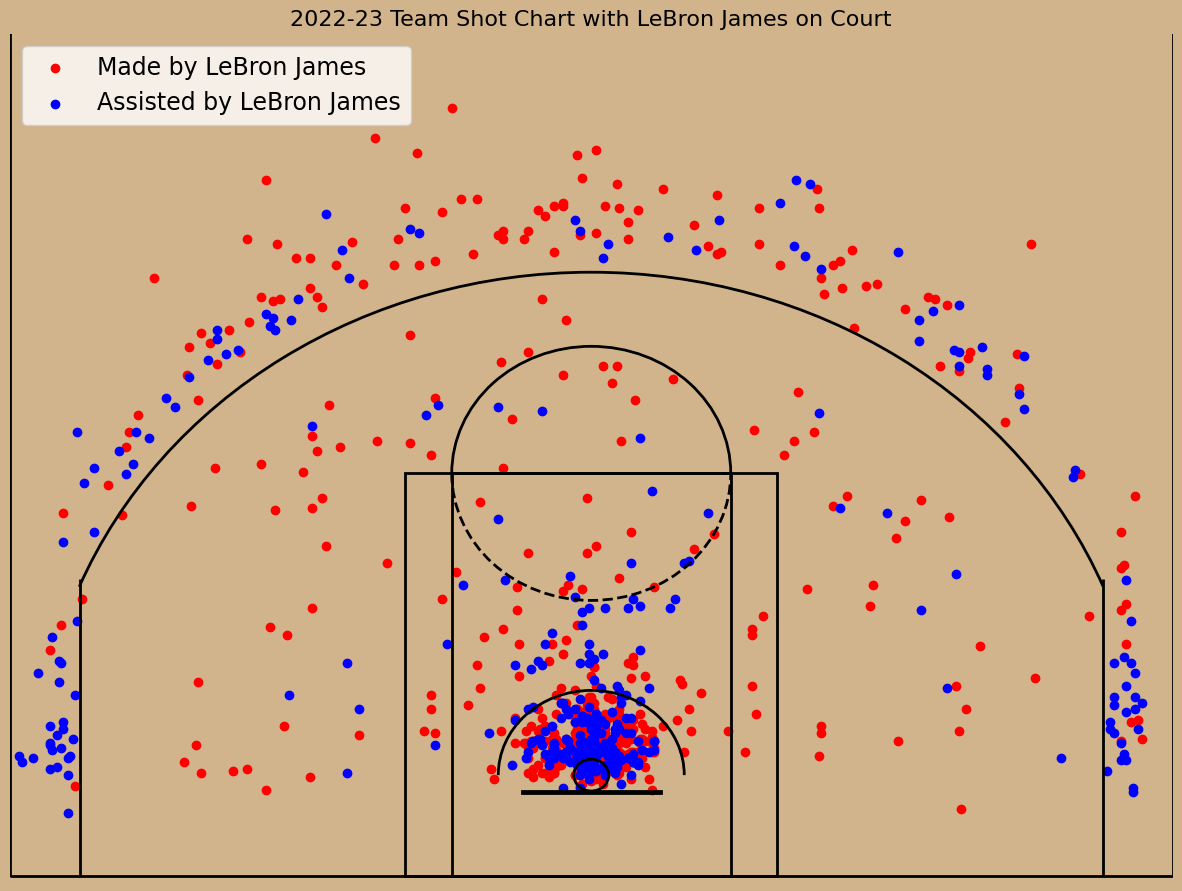

In [29]:
plot_shots_on_court(2544,2022)

In [30]:
import matplotlib.image as mpimg
from PIL import Image
import requests
from io import BytesIO
def hex_plot_on_court(player,season):
    plot =on_court_plays(player,season)
    norm = mpl.colors.Normalize()
    fig = plt.figure(figsize=(15,11))
    ax = fig.add_subplot(111)
    ax.hexbin(plot.LOC_X, plot.LOC_Y, gridsize=25, bins='log', cmap='inferno',
               mincnt= (plot.shape[0])*.0025)
    draw_court(outer_lines=True, color="black")
    plt.xlim(-250,250)
    plt.ylim(-50,350)
    plt.axis('off')
    plt.title('2022-23 Team Shot Chart with {} on Court'.format(working_player_dict[player]),
               size=16)
    
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='inferno'),  ax=ax,
                label='Frequency', orientation='horizontal')
    
    url = 'https://cdn.nba.com/headshots/nba/latest/1040x760/{}.png'.format(player)
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    
    # Place image in the top right corner
    newax = fig.add_axes([0.77, 0.77, 0.125, 0.125], anchor='NE', zorder=1)
    newax.imshow(img)
    newax.axis('off')

    plt.show()


In [31]:
df3= off_court_plays(1630567,2022)
df3['Player_filter'] = working_player_dict[1630567]
df3 = df3[['Player_filter', 'LOC_X', 'LOC_Y']]
df3.to_numpy()

array([['Scottie Barnes', -12, 14],
       ['Scottie Barnes', -21, 59],
       ['Scottie Barnes', 97, 227],
       ...,
       ['Scottie Barnes', -172, 219],
       ['Scottie Barnes', 13, 6],
       ['Scottie Barnes', 234, -1]], shape=(3648, 3), dtype=object)

In [32]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def similarity_check(player, year):
    # Get shot locations
    matrix_on = on_court_plays(player, year)[['LOC_X', 'LOC_Y']].to_numpy()
    matrix_off = off_court_plays(player, year)[['LOC_X', 'LOC_Y']].to_numpy()

    # Define court bins
    x_bins = np.linspace(-250, 250, 25)  # adjust as needed
    y_bins = np.linspace(-50, 470, 25)   # adjust as needed

    # Create 2D histograms
    hist_on, _, _ = np.histogram2d(matrix_on[:,0], matrix_on[:,1], bins=[x_bins, y_bins])
    hist_off, _, _ = np.histogram2d(matrix_off[:,0], matrix_off[:,1], bins=[x_bins, y_bins])

    # Flatten histograms
    vector_on = hist_on.flatten().reshape(1, -1)
    vector_off = hist_off.flatten().reshape(1, -1)

    # Compute similarity
    score = cosine_similarity(vector_on, vector_off)[0][0]

    return "{}'s shot profile similarity is {}".format(working_player_dict[player], score)

In [33]:
similarity_check(201939,2022)

"Stephen Curry's shot profile similarity is 0.9773096600071127"

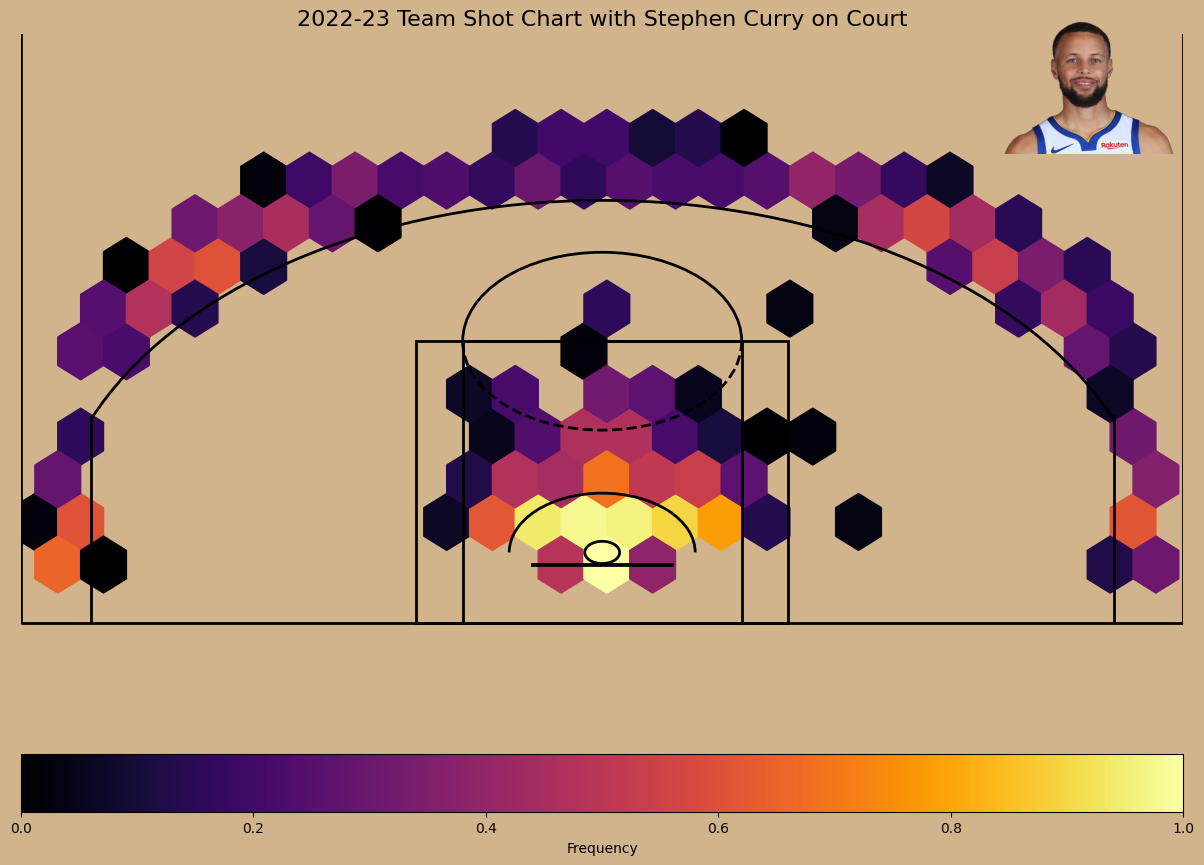

In [34]:
hex_plot_on_court(201939,2022)

In [35]:
import nba_api.stats.static.teams as team

In [36]:
teams = team.get_teams()[0]
teams

{'id': 1610612737,
 'full_name': 'Atlanta Hawks',
 'abbreviation': 'ATL',
 'nickname': 'Hawks',
 'city': 'Atlanta',
 'state': 'Georgia',
 'year_founded': 1949}

In [37]:
logs.get_data_frames()[0].loc[:3, 'MATCHUP']

0      TOR @ SAS
1      TOR @ DAL
2    TOR vs. CHA
3    TOR vs. POR
Name: MATCHUP, dtype: object

In [48]:
from nba_api.stats.endpoints import leagueleaders
import pandas as pd

# Fetch players for a specific season
leaderboard = leagueleaders.LeagueLeaders(season='1996-97')
df = leaderboard.league_leaders.get_data_frame()

# Display unique players active that season
print(df['PLAYER_ID'].unique())
df


[ 893  252  779  782   84  165  383  947   56  121  397  255  299  711
  339  937  896  452  757  436  210  431  949  693  363  185  120   72
  952  134  393  224  107  302  686  954  406  297  708  938  714  133
  754  361  375  919  735  358   89  111 1005  275  204  193  304  103
   57  296  283  247  922 1122  904  765   17  951  445  907  677  168
  915   87  317  950  324  330  901  934   51  178  124   96  787  209
  221  913  208  762  238  739  948  137  717  722   53  364  702  239
  423   64   22  219  718  935  198  184  891  213  371  786  270  788
  384  905  192  469  145  349  422  899 1134   49  179  123 1074  417
  428  136   98  682  389  696  157   76  182  271  390  400  288  895
   70  894   45  707  448   21  461  164  156  467  920   61   42  911
  251  724   55  381  345  763  781  386  953  731  216  435  420  679
  441 1051   73  977   26   63   28    2  177  234   67  721  147  166
  898  760  143  433  958  734  240  923  699  689  761  243   43  698
  109 

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,893,1,Michael Jordan,1610612741,CHI,82,3109,920,1892,0.486,...,482,352,140,44,166,156,2431,2215,2.12,0.84
1,252,2,Karl Malone,1610612762,UTA,82,2998,864,1571,0.550,...,809,368,113,48,233,217,2249,2478,1.58,0.49
2,779,3,Glen Rice,1610612766,CHH,79,3359,722,1513,0.477,...,318,160,72,26,177,190,2115,1652,0.90,0.41
3,782,4,Mitch Richmond,1610612758,SAC,81,3115,717,1578,0.454,...,319,338,118,24,237,211,2095,1722,1.43,0.50
4,84,5,Latrell Sprewell,1610612744,GSW,80,3350,649,1444,0.449,...,366,507,132,45,322,153,1938,1779,1.58,0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,292,437,Anthony Miller,1610612737,ATL,1,14,0,5,0.000,...,7,0,0,0,0,2,0,2,0.00,0.00
429,1477,437,Bruce Bowen,1610612748,MIA,1,1,0,0,0.000,...,0,0,0,1,0,0,0,1,0.00,0.00
430,733,437,Cuonzo Martin,1610612749,MIL,3,13,0,7,0.000,...,1,1,0,0,1,1,0,-6,1.00,0.00
431,308,437,Derrick Alston,1610612737,ATL,2,11,0,5,0.000,...,4,0,0,0,0,0,0,-3,0.00,0.00
